In [219]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
from hedging import run_delta_hedge_analysis, run_delta_vega_hedge_analysis
import matplotlib.pyplot as plt

In [220]:
ticker = 'AAPL'
dataraw = pd.read_csv(f"AAPL_processed_vega.csv")

data = dataraw.copy()

# Define conditions and choices
conditions = [
    data['delta_start'] < 0.3,
    data['delta_start'] > 0.7,
    (data['delta_start'] >= 0.35) & (data['delta_start'] <= 0.65)
]

choices = ['OTM', 'ITM', 'ATM']

# Apply conditions
data['initial_moneyness'] = np.select(conditions, choices, default=data['initial_moneyness'])


data['date'] = pd.to_datetime(data['date'])
data['expiration_date'] = pd.to_datetime(data['expiration_date'])

In [221]:
per_option = (
    data[['option_id', 'K', 'expiration_date']]
    .drop_duplicates()
)

expiries = sorted(per_option['expiration_date'].unique())
next_expiry_map = {}
for i in range(len(expiries) - 1):
    next_expiry_map[expiries[i]] = expiries[i+1]

per_option['next_expiration'] = per_option['expiration_date'].map(next_expiry_map)  #add to per option the next expiration date 

In [222]:
#create option pairs

# Left: options at T1
left = per_option.dropna(subset=['next_expiration']).copy()

# Right: potential hedge options at T2
right = per_option.rename(
    columns={
        'option_id': 'hedge_option_id',
        'expiration_date': 'hedge_expiration'
    }
)

# Merge on strike + matching T2
pairs = left.merge(
    right,
    left_on=['K', 'next_expiration'],
    right_on=['K', 'hedge_expiration'],
    how='inner'
)

# pairs now has: option_id (T1) and hedge_option_id (T2) with same K
print(pairs[['option_id', 'expiration_date', 'K',
             'hedge_option_id', 'hedge_expiration']].head())
print("Number of hedgeable options:", pairs['option_id'].nunique())


              option_id expiration_date      K       hedge_option_id  \
0  AAPL_2020-09-18_K115      2020-09-18  115.0  AAPL_2020-10-16_K115   
1  AAPL_2020-09-18_K120      2020-09-18  120.0  AAPL_2020-10-16_K120   
2  AAPL_2020-09-18_K125      2020-09-18  125.0  AAPL_2020-10-16_K125   
3  AAPL_2020-10-16_K115      2020-10-16  115.0  AAPL_2020-11-20_K115   
4  AAPL_2020-10-16_K120      2020-10-16  120.0  AAPL_2020-11-20_K120   

  hedge_expiration  
0       2020-10-16  
1       2020-10-16  
2       2020-10-16  
3       2020-11-20  
4       2020-11-20  
Number of hedgeable options: 145


In [223]:
moneness_info = (
    data[['option_id', 'initial_moneyness']]
    .drop_duplicates()
)

# merge onto pairs
pairs = pairs.merge(moneness_info, on='option_id', how='left')

# count how many *hedgeable* options per moneyness
hedgeable_counts = (
    pairs.groupby('initial_moneyness')['option_id']
         .nunique()
         .sort_index()
)

print("Hedgeable options per moneyness:")
print(hedgeable_counts)

Hedgeable options per moneyness:
initial_moneyness
ATM      8
ITM     11
OTM    126
Name: option_id, dtype: int64


## AAAAAAA

In [224]:
per_option = (
    data[['option_id', 'K', 'expiration_date']]
    .drop_duplicates()
    .copy()
)

# make sure expiration_date is datetime
per_option['expiration_date'] = pd.to_datetime(per_option['expiration_date'])

expiries = sorted(per_option['expiration_date'].unique())

# map T1 → T2
next_expiry_map = {
    expiries[i]: expiries[i+1]
    for i in range(len(expiries) - 1)
}

per_option['next_expiration'] = per_option['expiration_date'].map(next_expiry_map)

# Left = target option (shorter maturity)
left = per_option.dropna(subset=['next_expiration']).copy()

# Right = hedge option (longer maturity), rename for clarity
right = per_option.rename(columns={
    'option_id': 'hedge_option_id',
    'expiration_date': 'hedge_expiration'
})

pairs = left.merge(
    right,
    left_on=['K', 'next_expiration'],
    right_on=['K', 'hedge_expiration'],
    how='inner'
)

# to see how many hedgeable options exist per moneyness
moneness_info = (
    data[['option_id', 'initial_moneyness']]
    .drop_duplicates()
)

pairs = pairs.merge(moneness_info, on='option_id', how='left')

print(pairs['initial_moneyness'].value_counts())


initial_moneyness
OTM    126
ITM     11
ATM      8
Name: count, dtype: int64


In [225]:
pairs.head()

,option_id,K,expiration_date,next_expiration_x,hedge_option_id,hedge_expiration,next_expiration_y,initial_moneyness
0,AAPL_2020-09-18_K115,115.0,2020-09-18,2020-10-16,AAPL_2020-10-16_K115,2020-10-16,2020-11-20,OTM
1,AAPL_2020-09-18_K120,120.0,2020-09-18,2020-10-16,AAPL_2020-10-16_K120,2020-10-16,2020-11-20,OTM
2,AAPL_2020-09-18_K125,125.0,2020-09-18,2020-10-16,AAPL_2020-10-16_K125,2020-10-16,2020-11-20,OTM
3,AAPL_2020-10-16_K115,115.0,2020-10-16,2020-11-20,AAPL_2020-11-20_K115,2020-11-20,2020-12-18,OTM
4,AAPL_2020-10-16_K120,120.0,2020-10-16,2020-11-20,AAPL_2020-11-20_K120,2020-11-20,2020-12-18,OTM


In [226]:
frequencies = [1, 2, 3, 7]

delta_vega_summary = run_delta_vega_hedge_analysis(
    data=data,   #historical value
    pairs=pairs, #replicating
    frequencies=frequencies
)


In [227]:
aggregated_deltavega_summary = (
    delta_vega_summary
    .groupby(['hedge_frequency', 'initial_moneyness'])['mse']
    .agg(
        mean_mse='mean',
        std_mse='std',
        n_options='count'
    )
    .reset_index()
)

aggregated_deltavega_summary['initial_moneyness'] = pd.Categorical(
    aggregated_deltavega_summary['initial_moneyness'],
    categories=moneyness_levels,
    ordered=True
)

aggregated_deltavega_summary = aggregated_deltavega_summary.sort_values([
    'hedge_frequency',
    'initial_moneyness'
])
aggregated_deltavega_summary.head()

,hedge_frequency,initial_moneyness,mean_mse,std_mse,n_options
1,1,ITM,0.080638,0.061116,10
0,1,ATM,0.021613,0.028341,8
2,1,OTM,0.042718,0.213082,122
4,2,ITM,0.091610,0.063544,10
3,2,ATM,0.025768,0.031168,8


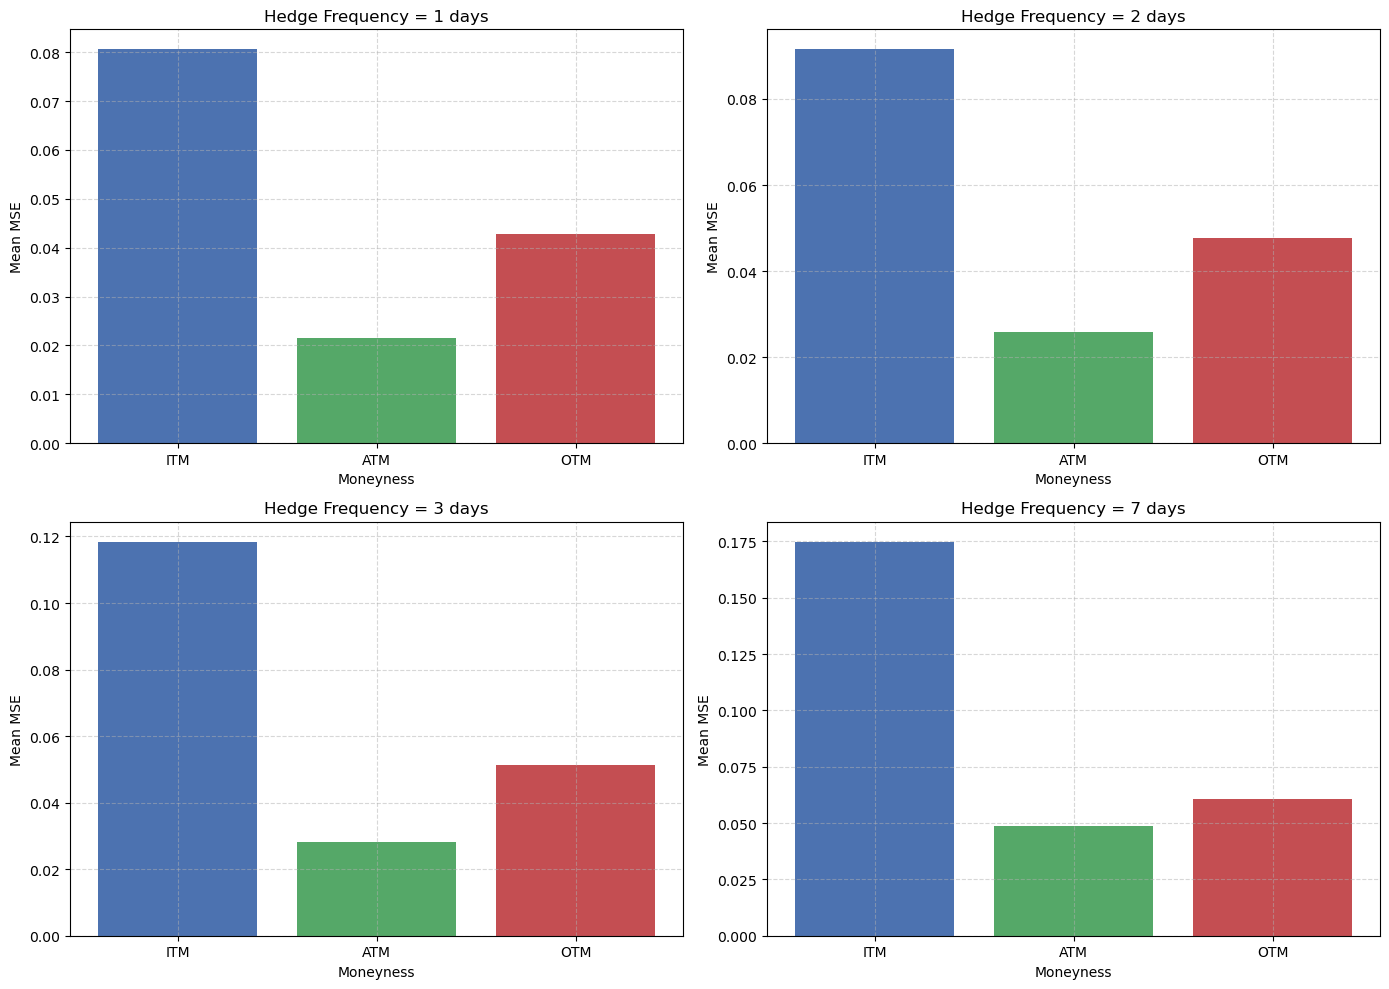

In [228]:
# Use this depending on your summary source:
df = aggregated_deltavega_summary   # or delta_summary

# Define order
frequencies = [1, 2, 3, 7]
moneyness_levels = ["ITM", "ATM", "OTM"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, freq in enumerate(frequencies):
    ax = axes[idx]

    # Filter data for this frequency
    d = df[df['hedge_frequency'] == freq]

    # Compute mean MSE per moneyness
    means = (
        d.groupby("initial_moneyness", observed=True)['mean_mse']
        .mean()
        .reindex(moneyness_levels)
    )

    # Plot bar chart
    ax.bar(moneyness_levels, means.values, color=["#4C72B0", "#55A868", "#C44E52"])

    ax.set_title(f"Hedge Frequency = {freq} days")
    ax.set_xlabel("Moneyness")
    ax.set_ylabel("Mean MSE")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [229]:
aggregated_freq = (
    delta_vega_summary
    .groupby('hedge_frequency')['mse']
    .agg(
        mean_mse="mean",
        std_mse="std",
        n_options="count"
    )
    .reset_index()
    .sort_values("hedge_frequency")
)
aggregated_freq

,hedge_frequency,mean_mse,std_mse,n_options
0,1,0.044221,0.199834,140
1,2,0.049638,0.207104,140
2,3,0.054680,0.222508,140
3,7,0.068076,0.228353,140


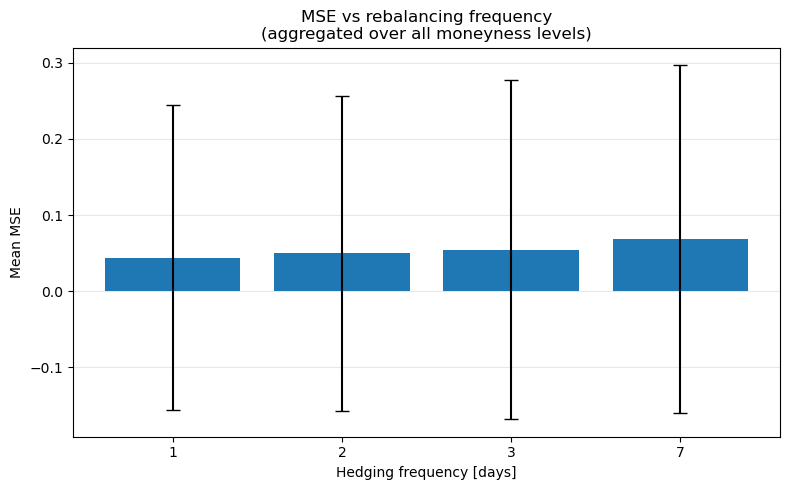

In [230]:
plt.figure(figsize=(8, 5))

x = np.arange(len(aggregated_freq))
means = aggregated_freq["mean_mse"].values
stds = aggregated_freq["std_mse"].values
labels = aggregated_freq["hedge_frequency"].astype(str).tolist()

plt.bar(x, means, yerr=stds, capsize=5)
plt.xticks(x, labels)

plt.xlabel("Hedging frequency [days]")
plt.ylabel("Mean MSE")
plt.title("MSE vs rebalancing frequency\n(aggregated over all moneyness levels)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

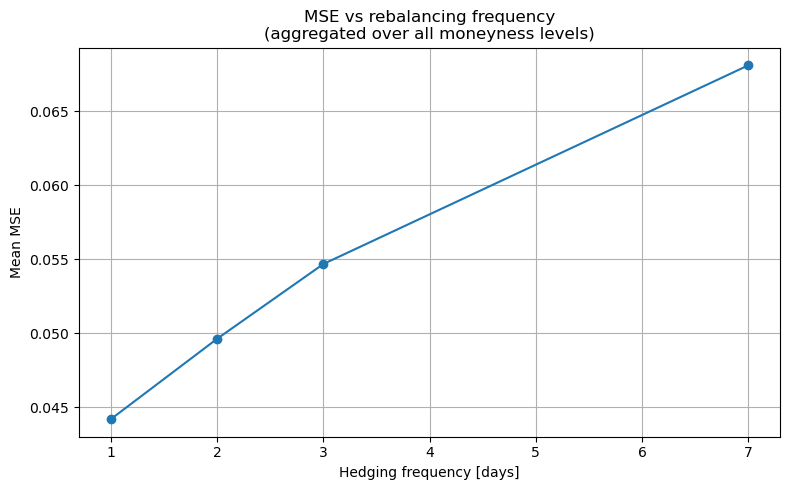

In [231]:
# for showing monotonicity
plt.figure(figsize=(8, 5))

plt.errorbar(
    aggregated_freq["hedge_frequency"],
    aggregated_freq["mean_mse"],
    fmt="o-",
    capsize=5
)

plt.xlabel("Hedging frequency [days]")
plt.ylabel("Mean MSE")
plt.title("MSE vs rebalancing frequency\n(aggregated over all moneyness levels)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [232]:
aggregated_deltavega_summary.head()

,hedge_frequency,initial_moneyness,mean_mse,std_mse,n_options
1,1,ITM,0.080638,0.061116,10
0,1,ATM,0.021613,0.028341,8
2,1,OTM,0.042718,0.213082,122
4,2,ITM,0.091610,0.063544,10
3,2,ATM,0.025768,0.031168,8


In [233]:
pivot_mse = aggregated_deltavega_summary.pivot(
    index='initial_moneyness',
    columns='hedge_frequency',
    values='mean_mse'
)

pivot_std = aggregated_deltavega_summary.pivot(
    index='initial_moneyness',
    columns='hedge_frequency',
    values='std_mse'
)
pivot_mse


hedge_frequency,1,2,3,7
initial_moneyness,,,,
ITM,0.080638,0.091610,0.118480,0.174966
ATM,0.021613,0.025768,0.028026,0.048678
OTM,0.042718,0.047763,0.051198,0.060587


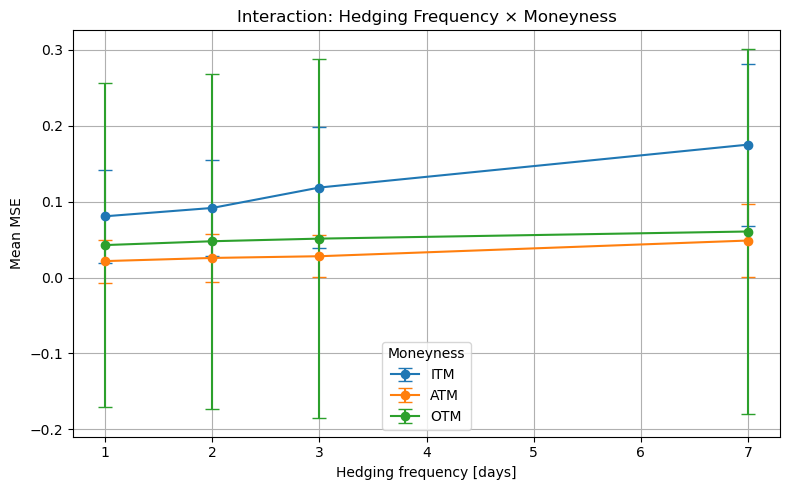

In [234]:
plt.figure(figsize=(8, 5))
for mon in moneyness_levels:
    df_mon = aggregated_deltavega_summary[aggregated_deltavega_summary["initial_moneyness"] == mon]
    plt.errorbar(
        df_mon["hedge_frequency"],
        df_mon["mean_mse"],
        yerr=df_mon["std_mse"],
        capsize=5,
        marker="o",
        label=mon
    )

plt.xlabel("Hedging frequency [days]")
plt.ylabel("Mean MSE")
plt.title("Interaction: Hedging Frequency × Moneyness")
plt.legend(title="Moneyness")
plt.grid(True)
plt.tight_layout()
plt.show()